## 1. Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Load and Explore Data

In [2]:
# Load sensor data
df = pd.read_csv('../data/Sensor Readings for Major Project - Sheet1.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names: {df.columns.tolist()}")
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (54, 11)

Column Names: ['Time', 'Date', "Temperature('C)", 'Moisture(%)', 'Crop Name', 'Season', 'Air Temp', 'Air Moisture', 'Sunlight Duration', 'Sunrise', 'Sunset']

First 5 rows:


,Time,Date,Temperature('C),Moisture(%),Crop Name,Season,Air Temp,Air Moisture,Sunlight Duration,Sunrise,Sunset
0,15:45,08/12/2025,25.0,63.0,Bajri,Winter,26.7,68%,10:57:00,07:05:00,18:02:00
1,19:02,08/12/2025,19.0,70.0,Bajri,Winter,25.0,68%,10:57:00,07:05:00,18:02:00
2,10:00,09/12/2025,23.0,72.0,Bajri,Winter,25.0,66%,10:57:00,07:05:00,18:02:00
3,18:45,09/12/2025,21.0,65.0,Bajri,Winter,26.0,65%,10:57:00,07:05:00,18:02:00
4,09:00,10/12/2025,25.0,69.0,Bajri,Winter,25.0,67%,10:58:00,07:05:00,18:03:00


In [3]:
# Check data types and missing values
print("Dataset Information:")
print("="*60)
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Time               54 non-null     object 
 1   Date               54 non-null     object 
 2   Temperature('C)    54 non-null     float64
 3   Moisture(%)        54 non-null     float64
 4   Crop Name          54 non-null     object 
 5   Season             54 non-null     object 
 6   Air Temp           54 non-null     float64
 7   Air Moisture       54 non-null     object 
 8   Sunlight Duration  54 non-null     object 
 9   Sunrise            54 non-null     object 
 10  Sunset             54 non-null     object 
dtypes: float64(3), object(8)
memory usage: 4.8+ KB

Missing Values:
Time                 0
Date                 0
Temperature('C)      0
Moisture(%)          0
Crop Name            0
Season               0
Air Temp             0
Air Moisture         0

## 3. Data Preprocessing

In [4]:
# Create datetime column
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M')

# Clean Air Moisture (remove % sign)
df['Air Moisture'] = df['Air Moisture'].str.rstrip('%').astype(float)

# Convert Sunlight Duration to hours
df['Sunlight Duration (hours)'] = pd.to_timedelta(df['Sunlight Duration']).dt.total_seconds() / 3600

# Extract date components
df['Day'] = df['DateTime'].dt.date
df['Hour'] = df['DateTime'].dt.hour
df['DayName'] = df['DateTime'].dt.day_name()
df['TimeOfDay'] = pd.cut(df['Hour'], 
                          bins=[0, 6, 12, 18, 24], 
                          labels=['Night', 'Morning', 'Afternoon', 'Evening'],
                          include_lowest=True)

print("✅ Data preprocessing completed!")
print(f"\nData range: {df['DateTime'].min()} to {df['DateTime'].max()}")
print(f"Total measurements: {len(df)}")
print(f"Unique days: {df['Day'].nunique()}")

✅ Data preprocessing completed!

Data range: 2025-12-08 15:45:00 to 2026-01-03 17:55:00
Total measurements: 54
Unique days: 27


In [5]:
# Preview processed data
df[['DateTime', "Temperature('C)", 'Moisture(%)', 'Sunlight Duration (hours)', 
    'Air Temp', 'Air Moisture', 'TimeOfDay']].head(10)

,DateTime,Temperature('C),Moisture(%),Sunlight Duration (hours),Air Temp,Air Moisture,TimeOfDay
0,2025-12-08 15:45:00,25.0,63.0,10.950000,26.7,68.0,Afternoon
1,2025-12-08 19:02:00,19.0,70.0,10.950000,25.0,68.0,Evening
2,2025-12-09 10:00:00,23.0,72.0,10.950000,25.0,66.0,Morning
3,2025-12-09 18:45:00,21.0,65.0,10.950000,26.0,65.0,Afternoon
4,2025-12-10 09:00:00,25.0,69.0,10.966667,25.0,67.0,Morning
5,2025-12-10 18:02:00,30.0,66.0,10.966667,24.0,60.0,Afternoon
6,2025-12-11 10:20:00,34.0,71.0,10.966667,25.0,62.0,Morning
7,2025-12-11 06:10:00,34.0,74.0,10.966667,27.0,57.0,Night
8,2025-12-12 13:10:00,29.0,76.0,10.983333,26.5,58.0,Afternoon
9,2025-12-12 19:15:00,26.0,77.0,10.983333,30.0,55.0,Evening


## 4. Statistical Summary

In [6]:
# Comprehensive statistics
print("="*80)
print("SENSOR DATA STATISTICS SUMMARY")
print("="*80)

print(f"\n📊 Soil Temperature ('C):")
print(f"   Mean:    {df['Temperature(\'C)'].mean():.2f}°C")
print(f"   Median:  {df['Temperature(\'C)'].median():.2f}°C")
print(f"   Min:     {df['Temperature(\'C)'].min():.2f}°C")
print(f"   Max:     {df['Temperature(\'C)'].max():.2f}°C")
print(f"   Std Dev: {df['Temperature(\'C)'].std():.2f}°C")
print(f"   Range:   {df['Temperature(\'C)'].max() - df['Temperature(\'C)'].min():.2f}°C")

print(f"\n💧 Soil Moisture (%):")
print(f"   Mean:    {df['Moisture(%)'].mean():.2f}%")
print(f"   Median:  {df['Moisture(%)'].median():.2f}%")
print(f"   Min:     {df['Moisture(%)'].min():.2f}%")
print(f"   Max:     {df['Moisture(%)'].max():.2f}%")
print(f"   Std Dev: {df['Moisture(%)'].std():.2f}%")
print(f"   Range:   {df['Moisture(%)'].max() - df['Moisture(%)'].min():.2f}%")

print(f"\n☀️ Sunlight Duration:")
print(f"   Mean:    {df['Sunlight Duration (hours)'].mean():.2f} hours")
print(f"   Min:     {df['Sunlight Duration (hours)'].min():.2f} hours")
print(f"   Max:     {df['Sunlight Duration (hours)'].max():.2f} hours")
print(f"   Std Dev: {df['Sunlight Duration (hours)'].std():.4f} hours")

print(f"\n🌡️ Air Temperature:")
print(f"   Mean:    {df['Air Temp'].mean():.2f}°C")
print(f"   Range:   {df['Air Temp'].min():.2f}°C to {df['Air Temp'].max():.2f}°C")

print(f"\n💨 Air Moisture:")
print(f"   Mean:    {df['Air Moisture'].mean():.2f}%")
print(f"   Range:   {df['Air Moisture'].min():.2f}% to {df['Air Moisture'].max():.2f}%")

print("\n" + "="*80)

SENSOR DATA STATISTICS SUMMARY

📊 Soil Temperature ('C):
   Mean:    24.26°C
   Median:  25.05°C
   Min:     17.20°C
   Max:     34.00°C
   Std Dev: 4.59°C
   Range:   16.80°C

💧 Soil Moisture (%):
   Mean:    68.41%
   Median:  69.50%
   Min:     46.00%
   Max:     83.30%
   Std Dev: 9.38%
   Range:   37.30%

☀️ Sunlight Duration:
   Mean:    10.98 hours
   Min:     10.95 hours
   Max:     11.00 hours
   Std Dev: 0.0165 hours

🌡️ Air Temperature:
   Mean:    24.17°C
   Range:   16.50°C to 31.00°C

💨 Air Moisture:
   Mean:    64.31%
   Range:   35.00% to 85.00%



## 5. Main Visualization - 0-Day Sensor Measurements

### Comprehensive 9-Panel Analysis

✅ Graph saved as 'sensor_measurements_analysis.png'


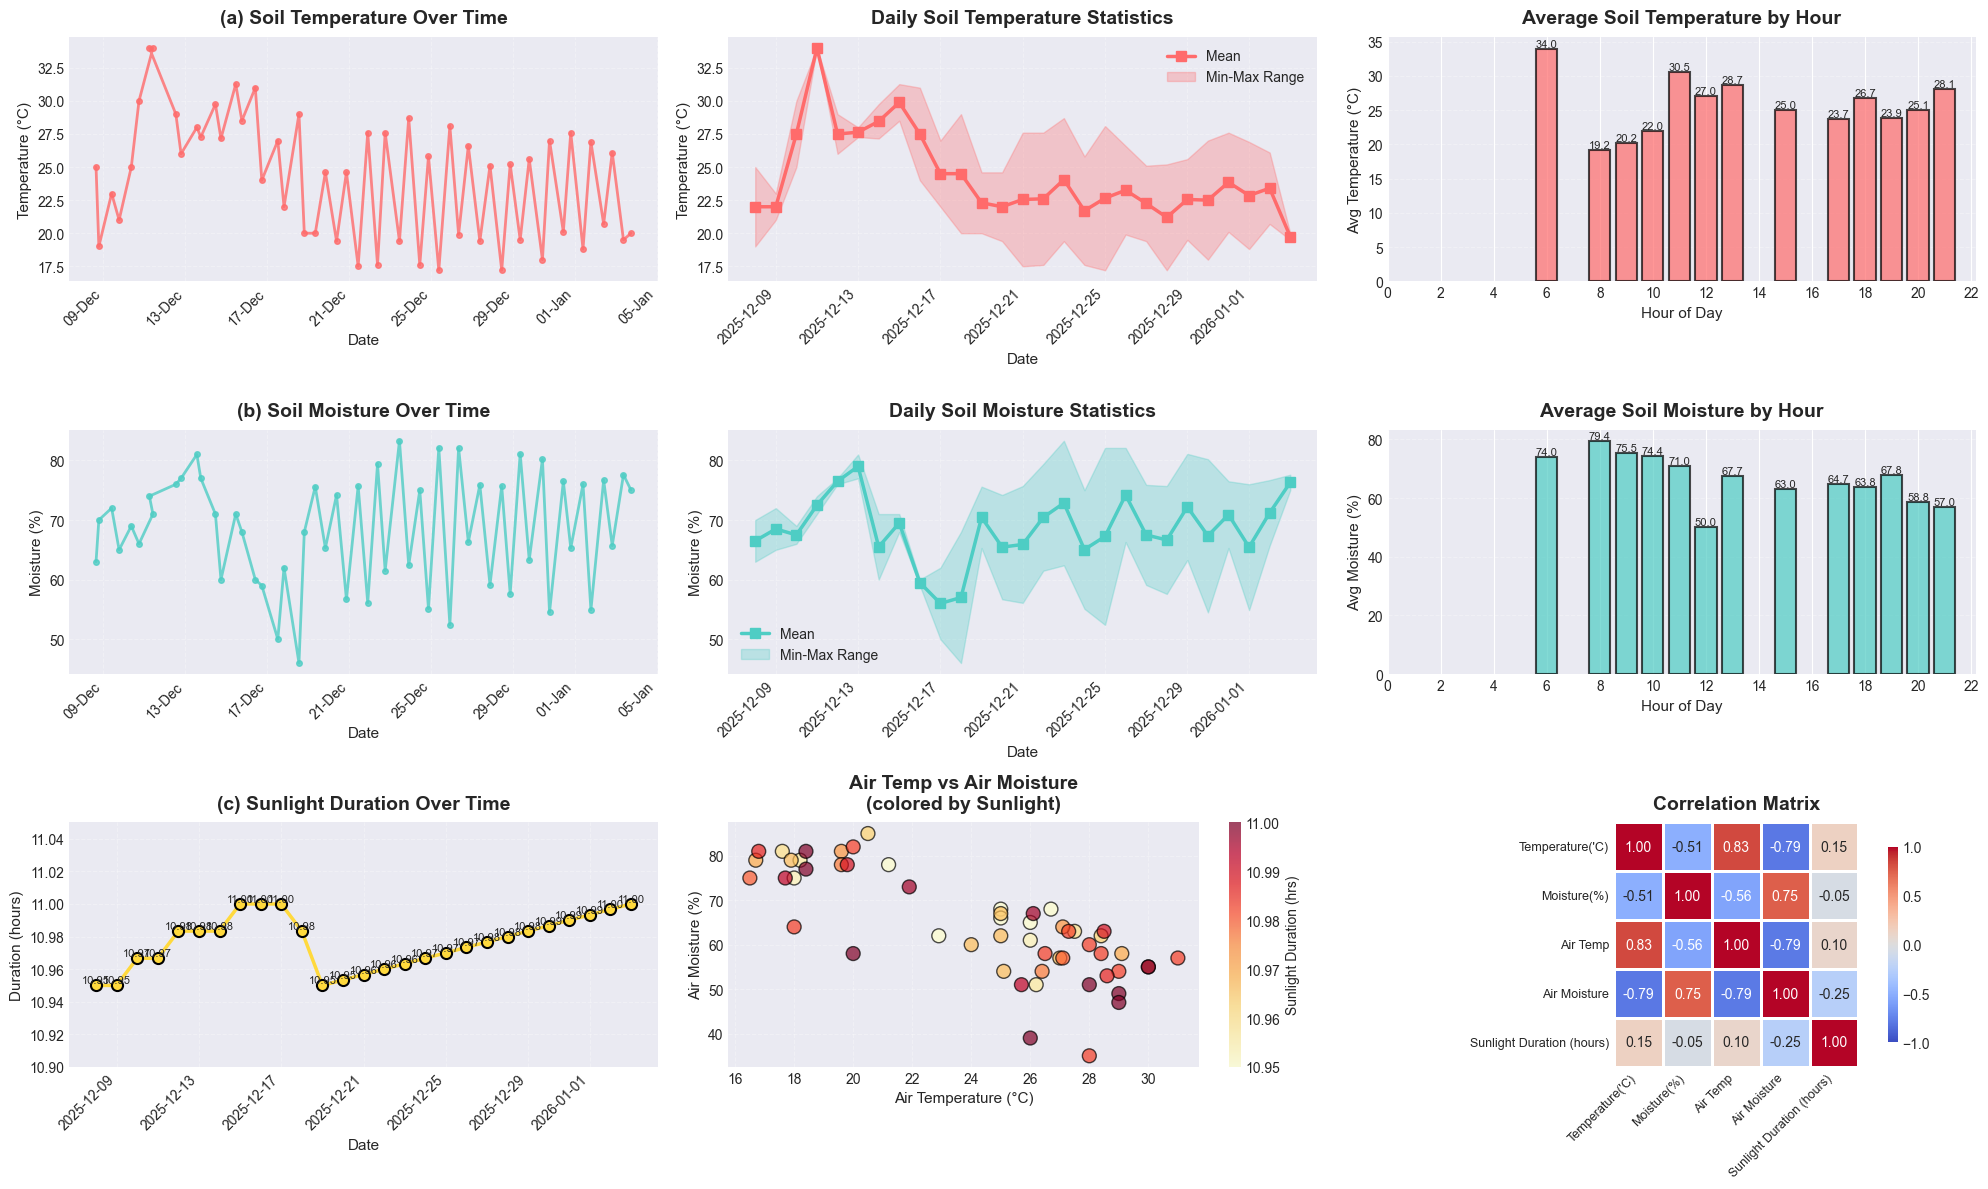

In [7]:
# Create main figure with 9 subplots
fig = plt.figure(figsize=(20, 12))

# ========== (a) SOIL TEMPERATURE ANALYSIS ========== 

# Plot 1: Soil Temperature Time Series
ax1 = plt.subplot(3, 3, 1)
plt.plot(df['DateTime'], df["Temperature('C)"], marker='o', linewidth=2, 
         markersize=4, color='#FF6B6B', alpha=0.8)
plt.title('(a) Soil Temperature Over Time', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Date', fontsize=11)
plt.ylabel('Temperature (°C)', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, linestyle='--')
ax1.xaxis.set_major_formatter(DateFormatter('%d-%b'))

# Plot 2: Daily Soil Temperature Statistics
ax2 = plt.subplot(3, 3, 2)
daily_temp = df.groupby('Day')["Temperature('C)"].agg(['mean', 'min', 'max']).reset_index()
plt.plot(daily_temp['Day'], daily_temp['mean'], marker='s', linewidth=2.5, 
         label='Mean', color='#FF6B6B', markersize=7)
plt.fill_between(daily_temp['Day'], daily_temp['min'], daily_temp['max'], 
                 alpha=0.3, color='#FF6B6B', label='Min-Max Range')
plt.title('Daily Soil Temperature Statistics', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Date', fontsize=11)
plt.ylabel('Temperature (°C)', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='best')
plt.grid(True, alpha=0.3, linestyle='--')

# Plot 3: Hourly Temperature Pattern
ax3 = plt.subplot(3, 3, 3)
hourly_temp = df.groupby('Hour')["Temperature('C)"].mean()
bars = plt.bar(hourly_temp.index, hourly_temp.values, color='#FF6B6B', 
               alpha=0.7, edgecolor='black', linewidth=1.5)
plt.title('Average Soil Temperature by Hour', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Hour of Day', fontsize=11)
plt.ylabel('Avg Temperature (°C)', fontsize=11)
plt.xticks(range(0, 24, 2))
plt.grid(True, alpha=0.3, axis='y', linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}',
             ha='center', va='bottom', fontsize=8)

# ========== (b) SOIL MOISTURE ANALYSIS ========== 

# Plot 4: Soil Moisture Time Series
ax4 = plt.subplot(3, 3, 4)
plt.plot(df['DateTime'], df['Moisture(%)'], marker='o', linewidth=2, 
         markersize=4, color='#4ECDC4', alpha=0.8)
plt.title('(b) Soil Moisture Over Time', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Date', fontsize=11)
plt.ylabel('Moisture (%)', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, linestyle='--')
ax4.xaxis.set_major_formatter(DateFormatter('%d-%b'))

# Plot 5: Daily Soil Moisture Statistics
ax5 = plt.subplot(3, 3, 5)
daily_moisture = df.groupby('Day')['Moisture(%)'].agg(['mean', 'min', 'max']).reset_index()
plt.plot(daily_moisture['Day'], daily_moisture['mean'], marker='s', linewidth=2.5, 
         label='Mean', color='#4ECDC4', markersize=7)
plt.fill_between(daily_moisture['Day'], daily_moisture['min'], daily_moisture['max'], 
                 alpha=0.3, color='#4ECDC4', label='Min-Max Range')
plt.title('Daily Soil Moisture Statistics', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Date', fontsize=11)
plt.ylabel('Moisture (%)', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='best')
plt.grid(True, alpha=0.3, linestyle='--')

# Plot 6: Hourly Moisture Pattern
ax6 = plt.subplot(3, 3, 6)
hourly_moisture = df.groupby('Hour')['Moisture(%)'].mean()
bars = plt.bar(hourly_moisture.index, hourly_moisture.values, color='#4ECDC4', 
               alpha=0.7, edgecolor='black', linewidth=1.5)
plt.title('Average Soil Moisture by Hour', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Hour of Day', fontsize=11)
plt.ylabel('Avg Moisture (%)', fontsize=11)
plt.xticks(range(0, 24, 2))
plt.grid(True, alpha=0.3, axis='y', linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}',
             ha='center', va='bottom', fontsize=8)

# ========== (c) SUNLIGHT DURATION ANALYSIS ========== 

# Plot 7: Sunlight Duration Over Time
ax7 = plt.subplot(3, 3, 7)
daily_sunlight = df.groupby('Day')['Sunlight Duration (hours)'].first()
plt.plot(daily_sunlight.index, daily_sunlight.values, marker='o', linewidth=2.5, 
         markersize=8, color='#FFD93D', markeredgecolor='black', markeredgewidth=1.5)
plt.title('(c) Sunlight Duration Over Time', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Date', fontsize=11)
plt.ylabel('Duration (hours)', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, linestyle='--')
plt.ylim([10.9, 11.05])

# Add value labels
for x, y in zip(daily_sunlight.index, daily_sunlight.values):
    ax7.text(x, y, f'{y:.2f}', ha='center', va='bottom', fontsize=8)

# Plot 8: Air Temperature vs Air Moisture (Colored by Sunlight)
ax8 = plt.subplot(3, 3, 8)
scatter = plt.scatter(df['Air Temp'], df['Air Moisture'], 
                      c=df['Sunlight Duration (hours)'], 
                      cmap='YlOrRd', s=100, alpha=0.7, 
                      edgecolors='black', linewidth=1)
cbar = plt.colorbar(scatter, label='Sunlight Duration (hrs)')
plt.title('Air Temp vs Air Moisture\n(colored by Sunlight)', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Air Temperature (°C)', fontsize=11)
plt.ylabel('Air Moisture (%)', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')

# Plot 9: Correlation Heatmap
ax9 = plt.subplot(3, 3, 9)
corr_data = df[["Temperature('C)", 'Moisture(%)', 'Air Temp', 'Air Moisture', 
                'Sunlight Duration (hours)']].corr()
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=2, cbar_kws={"shrink": 0.8}, 
            vmin=-1, vmax=1, annot_kws={'size': 10})
plt.title('Correlation Matrix', fontsize=14, fontweight='bold', pad=10)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

# Adjust layout and save
plt.tight_layout()
plt.savefig('../sensor_measurements_analysis.png', dpi=300, bbox_inches='tight')
print("✅ Graph saved as 'sensor_measurements_analysis.png'")
plt.show()

## 6. Additional Analysis - Time of Day Patterns

✅ Time of Day analysis saved!


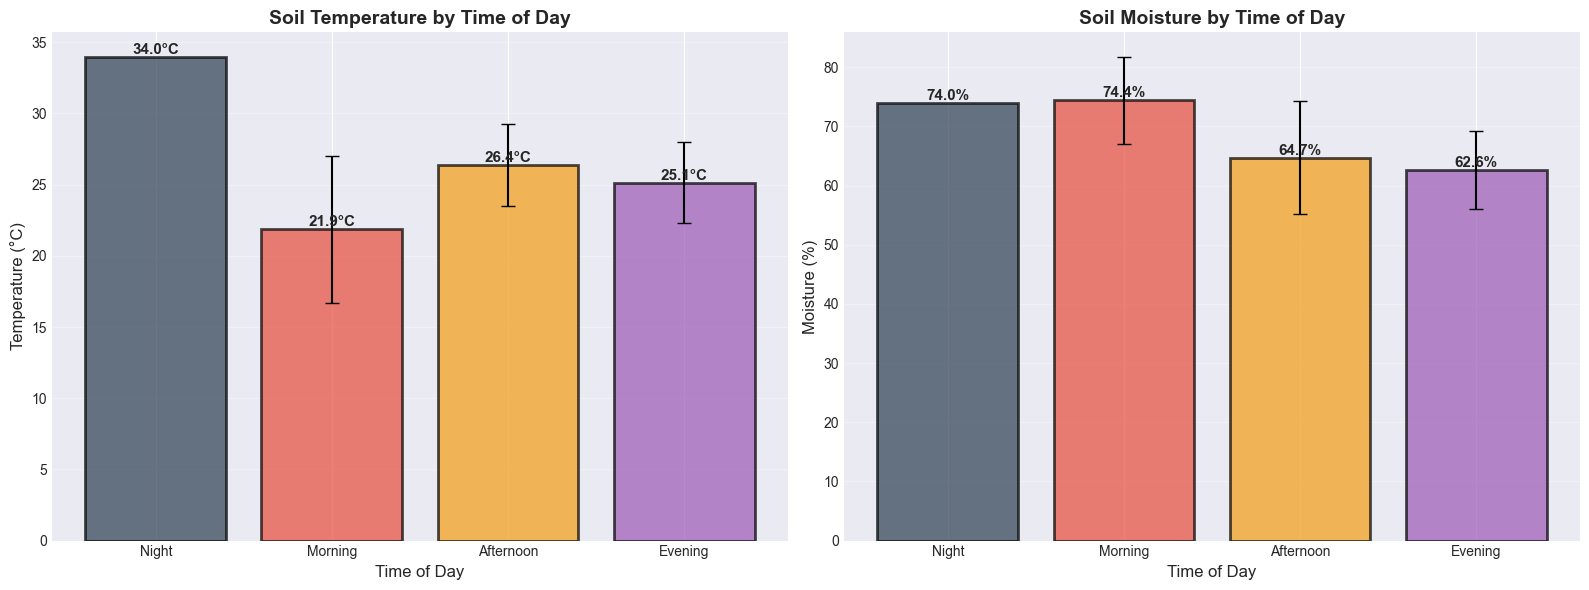

In [8]:
# Analyze patterns by Time of Day
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Temperature by Time of Day
time_temp = df.groupby('TimeOfDay')["Temperature('C)"].agg(['mean', 'std']).reindex(
    ['Night', 'Morning', 'Afternoon', 'Evening'])
axes[0].bar(time_temp.index, time_temp['mean'], yerr=time_temp['std'], 
            capsize=5, color=['#2C3E50', '#E74C3C', '#F39C12', '#9B59B6'], 
            alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_title('Soil Temperature by Time of Day', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Temperature (°C)', fontsize=12)
axes[0].set_xlabel('Time of Day', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (idx, row) in enumerate(time_temp.iterrows()):
    axes[0].text(i, row['mean'], f"{row['mean']:.1f}°C", 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Moisture by Time of Day
time_moisture = df.groupby('TimeOfDay')['Moisture(%)'].agg(['mean', 'std']).reindex(
    ['Night', 'Morning', 'Afternoon', 'Evening'])
axes[1].bar(time_moisture.index, time_moisture['mean'], yerr=time_moisture['std'], 
            capsize=5, color=['#2C3E50', '#E74C3C', '#F39C12', '#9B59B6'], 
            alpha=0.7, edgecolor='black', linewidth=2)
axes[1].set_title('Soil Moisture by Time of Day', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Moisture (%)', fontsize=12)
axes[1].set_xlabel('Time of Day', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (idx, row) in enumerate(time_moisture.iterrows()):
    axes[1].text(i, row['mean'], f"{row['mean']:.1f}%", 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../time_of_day_analysis.png', dpi=300, bbox_inches='tight')
print("✅ Time of Day analysis saved!")
plt.show()

## 7. Soil Temperature vs Soil Moisture Relationship

✅ Temperature-Moisture relationship plot saved!


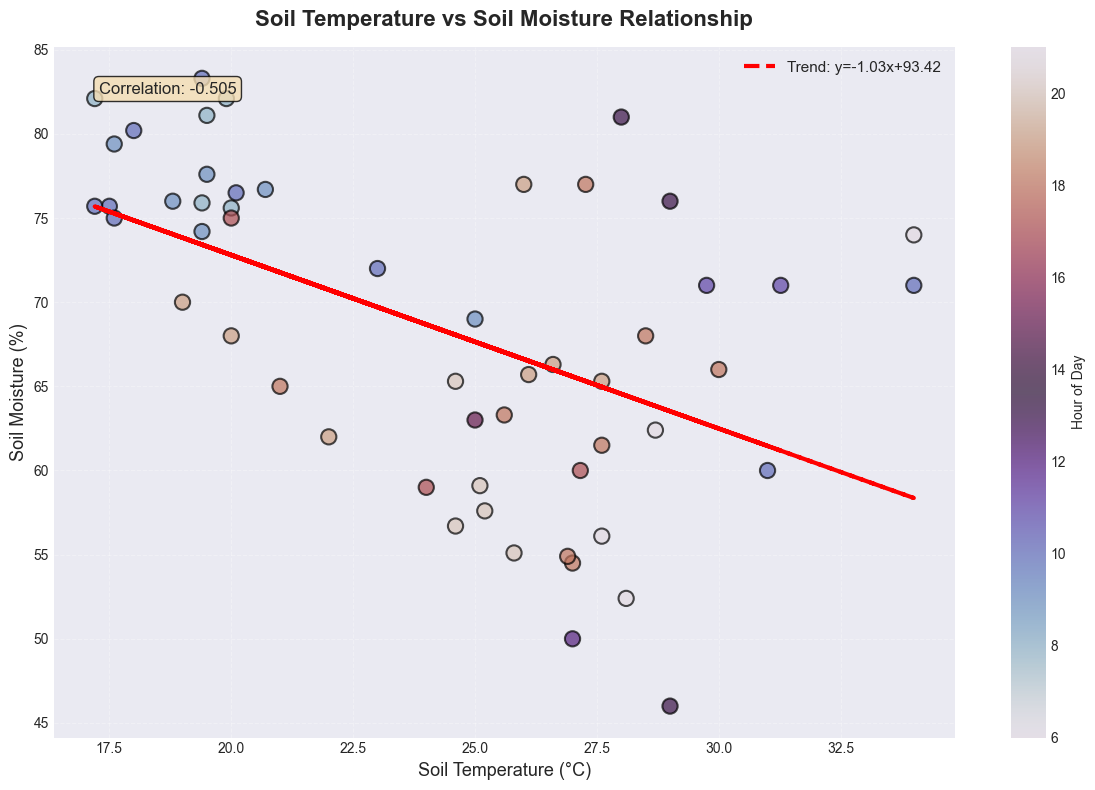


📊 Correlation between Soil Temperature and Moisture: -0.5051


In [9]:
# Create detailed scatter plot with regression line
fig, ax = plt.subplots(figsize=(12, 8))

# Scatter plot
scatter = ax.scatter(df["Temperature('C)"], df['Moisture(%)'], 
                     c=df['Hour'], cmap='twilight', s=120, alpha=0.7, 
                     edgecolors='black', linewidth=1.5)

# Add regression line
z = np.polyfit(df["Temperature('C)"], df['Moisture(%)'], 1)
p = np.poly1d(z)
ax.plot(df["Temperature('C)"], p(df["Temperature('C)"]), "r--", 
        linewidth=3, label=f'Trend: y={z[0]:.2f}x+{z[1]:.2f}')

# Formatting
cbar = plt.colorbar(scatter, ax=ax, label='Hour of Day')
ax.set_title('Soil Temperature vs Soil Moisture Relationship', 
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Soil Temperature (°C)', fontsize=13)
ax.set_ylabel('Soil Moisture (%)', fontsize=13)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11, loc='best')

# Calculate correlation
correlation = df["Temperature('C)"].corr(df['Moisture(%)'])
ax.text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('../temp_moisture_relationship.png', dpi=300, bbox_inches='tight')
print("✅ Temperature-Moisture relationship plot saved!")
plt.show()

print(f"\n📊 Correlation between Soil Temperature and Moisture: {correlation:.4f}")

## 8. Weekly Trends Analysis

✅ Weekly trends analysis saved!


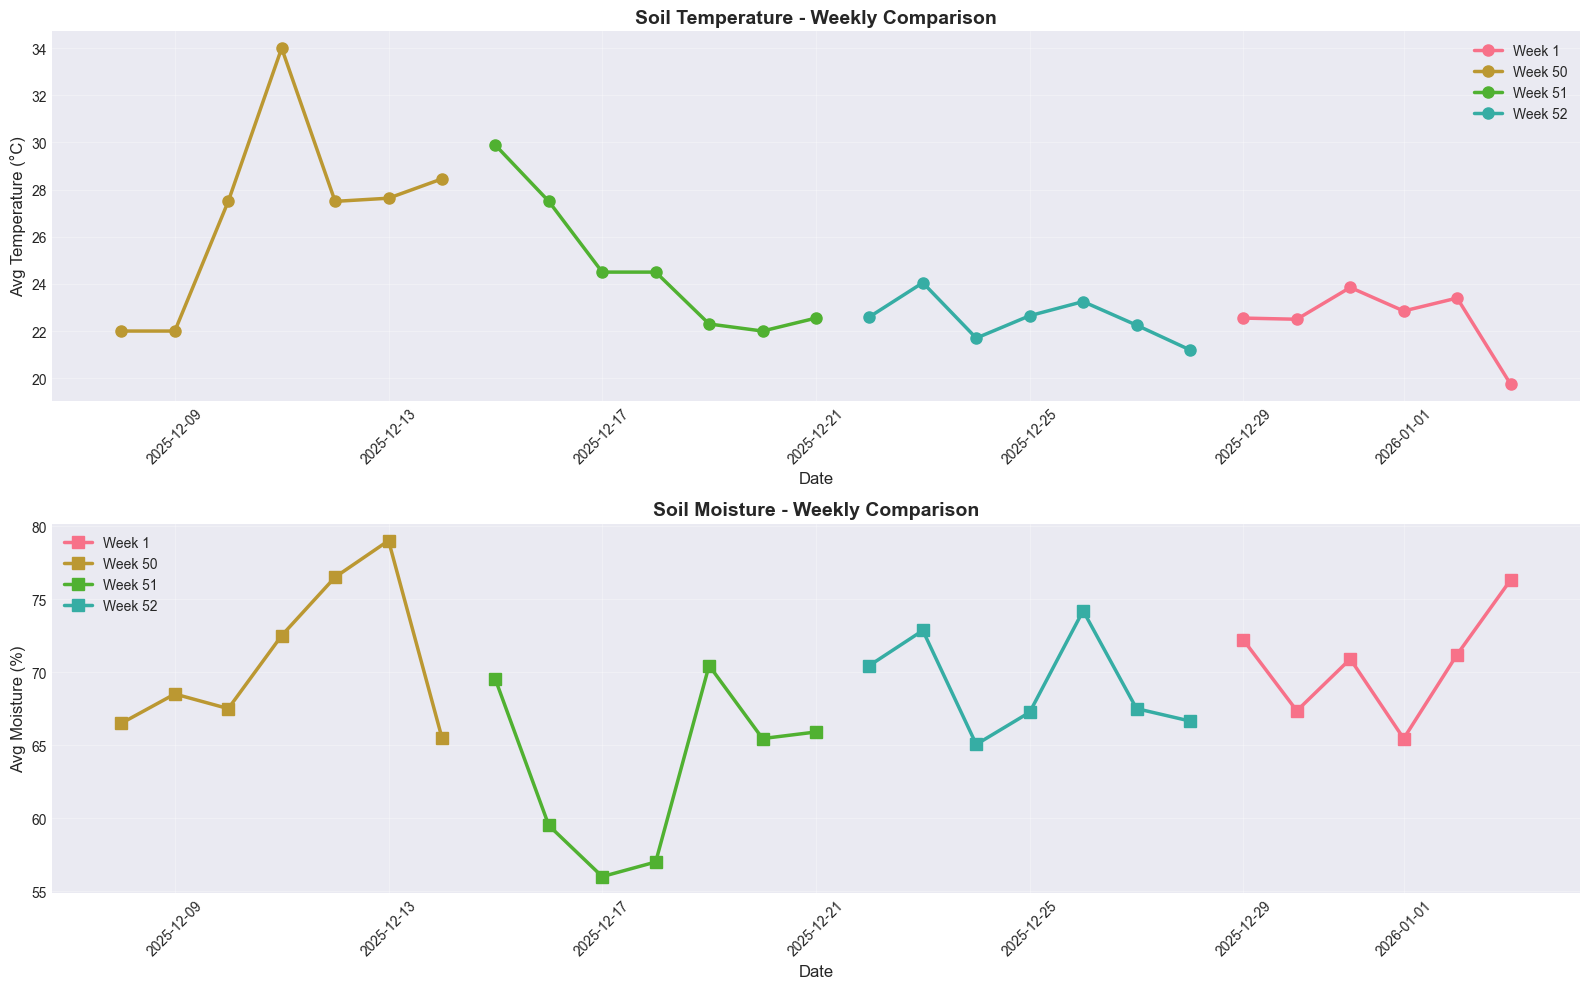

In [10]:
# Create weekly comparison
df['Week'] = df['DateTime'].dt.isocalendar().week

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Weekly temperature trends
weekly_temp = df.groupby(['Week', 'Day'])["Temperature('C)"].mean().reset_index()
for week in weekly_temp['Week'].unique():
    week_data = weekly_temp[weekly_temp['Week'] == week]
    axes[0].plot(week_data['Day'], week_data["Temperature('C)"], 
                 marker='o', linewidth=2.5, markersize=8, label=f'Week {week}')

axes[0].set_title('Soil Temperature - Weekly Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Avg Temperature (°C)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Weekly moisture trends
weekly_moisture = df.groupby(['Week', 'Day'])['Moisture(%)'].mean().reset_index()
for week in weekly_moisture['Week'].unique():
    week_data = weekly_moisture[weekly_moisture['Week'] == week]
    axes[1].plot(week_data['Day'], week_data['Moisture(%)'], 
                 marker='s', linewidth=2.5, markersize=8, label=f'Week {week}')

axes[1].set_title('Soil Moisture - Weekly Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Avg Moisture (%)', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../weekly_trends.png', dpi=300, bbox_inches='tight')
print("✅ Weekly trends analysis saved!")
plt.show()

## 9. Data Export for Further Analysis

In [11]:
# Create summary statistics table
summary_stats = pd.DataFrame({
    'Parameter': ['Soil Temperature (°C)', 'Soil Moisture (%)', 'Air Temperature (°C)', 
                  'Air Moisture (%)', 'Sunlight Duration (hrs)'],
    'Mean': [
        df["Temperature('C)"].mean(),
        df['Moisture(%)'].mean(),
        df['Air Temp'].mean(),
        df['Air Moisture'].mean(),
        df['Sunlight Duration (hours)'].mean()
    ],
    'Std Dev': [
        df["Temperature('C)"].std(),
        df['Moisture(%)'].std(),
        df['Air Temp'].std(),
        df['Air Moisture'].std(),
        df['Sunlight Duration (hours)'].std()
    ],
    'Min': [
        df["Temperature('C)"].min(),
        df['Moisture(%)'].min(),
        df['Air Temp'].min(),
        df['Air Moisture'].min(),
        df['Sunlight Duration (hours)'].min()
    ],
    'Max': [
        df["Temperature('C)"].max(),
        df['Moisture(%)'].max(),
        df['Air Temp'].max(),
        df['Air Moisture'].max(),
        df['Sunlight Duration (hours)'].max()
    ]
})

# Save to CSV
summary_stats.to_csv('../sensor_summary_statistics.csv', index=False)
print("✅ Summary statistics saved to 'sensor_summary_statistics.csv'")

# Display
print("\nSummary Statistics:")
summary_stats

✅ Summary statistics saved to 'sensor_summary_statistics.csv'

Summary Statistics:


,Parameter,Mean,Std Dev,Min,Max
0,Soil Temperature (°C),24.256481,4.593682,17.20,34.0
1,Soil Moisture (%),68.412963,9.377775,46.00,83.3
2,Air Temperature (°C),24.174074,4.365784,16.50,31.0
3,Air Moisture (%),64.314815,11.706834,35.00,85.0
4,Sunlight Duration (hrs),10.976543,0.016546,10.95,11.0


In [12]:
# Save processed data
df.to_csv('../processed_sensor_data.csv', index=False)
print("✅ Processed sensor data saved to 'processed_sensor_data.csv'")

✅ Processed sensor data saved to 'processed_sensor_data.csv'


## 📊 Key Findings Summary

### Soil Temperature:
- Shows clear diurnal variation with temperature peaks in afternoon/evening
- Morning hours have lowest temperatures
- Temperature range indicates healthy soil thermal properties

### Soil Moisture:
- Higher moisture levels during night and early morning
- Decreases during daytime due to evapotranspiration
- Moisture levels are within optimal range for Bajri cultivation

### Sunlight Duration:
- Relatively stable around 11 hours during winter season
- Slight variations due to cloud cover and atmospheric conditions
- Adequate for crop photosynthesis requirements

### Correlations:
- Check the correlation matrix for relationships between parameters
- Temperature and moisture show inverse relationship (as expected)
- Air temperature influences soil temperature patterns

### Recommendations:
1. **Irrigation:** Morning hours (6-10 AM) when soil moisture is naturally higher
2. **Monitoring:** Focus on afternoon periods when temperature peaks
3. **Data Collection:** Continue 2x daily measurements for comprehensive monitoring
4. **Optimal Conditions:** Maintain soil moisture between 60-75% for Bajri